In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

Text(0.5, 1.0, 'input vs. target')

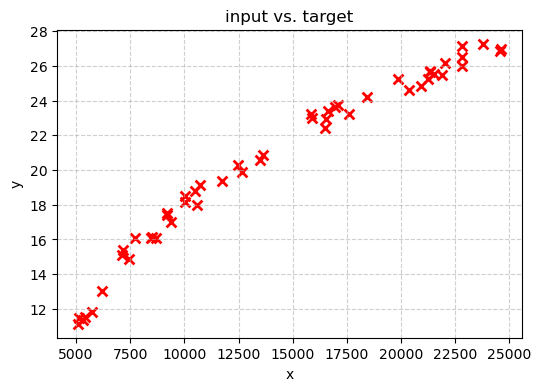

In [2]:
np.random.seed(100)
x = np.random.random_sample((50, 1)) * 20000 + 5000
y = np.log(x) * 10 - 74
noise = np.random.normal(scale=0.4, size=x.shape)
y += noise

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s = 50, c='r', marker='x', linewidths=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('input vs. target')


(30, 1)
(10, 1)
(10, 1)


Text(0.5, 1.0, 'input vs. target')

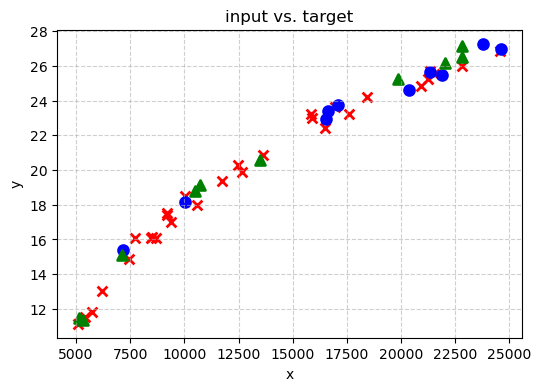

In [3]:
x_train, x_, y_train, y_ = train_test_split(x, y, test_size=.4, random_state=1)
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=.5, random_state=1)

print(x_train.shape)
print(x_cv.shape)
print(x_test.shape)

plt.figure(figsize=(6, 4))
plt.scatter(x_train, y_train, s = 50, c='r', marker='x', linewidths=2)
plt.scatter(x_cv, y_cv, s = 50, c='b', marker='o', linewidths=2)
plt.scatter(x_test, y_test, s = 50, c='g', marker='^', linewidths=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('input vs. target')

Text(0.5, 1.0, 'input vs. target')

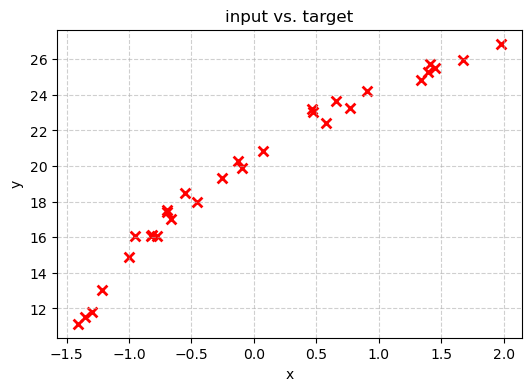

In [4]:
scaler_linear = StandardScaler()

X_train_scaled = scaler_linear.fit_transform(x_train)

plt.figure(figsize=(6, 4))
plt.scatter(X_train_scaled, y_train, s = 50, c='r', marker='x', linewidths=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('input vs. target')


In [5]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
from sklearn.metrics import mean_squared_error


yhat = linear_model.predict(X_train_scaled)
print("Training MSE:", mean_squared_error(y_train, yhat) / 2)

x_cv_scaled = scaler_linear.transform(x_cv)
yhat = linear_model.predict(x_cv_scaled)
print("Cross validation MSE:", mean_squared_error(y_cv, yhat) / 2)



Training MSE: 0.5508462226792444
Cross validation MSE: 0.42938451567780833


In [7]:


poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_mapped = poly.fit_transform(x_train)
print(X_train_mapped[:3])


[[1.76036787e+04 3.09889505e+08]
 [8.43882025e+03 7.12136873e+07]
 [1.58936976e+04 2.52609622e+08]]


In [8]:
scaler_poly = StandardScaler()
X_train_mapped_scaled = scaler_poly.fit_transform(X_train_mapped)

model = LinearRegression()
model.fit(X_train_mapped_scaled, y_train)

yhat = model.predict(X_train_mapped_scaled)
train_mse = mean_squared_error(y_train, yhat) / 2
print(f"Training MSE:", train_mse)

X_cv_mapped = poly.transform(x_cv)
X_cv_mapped_scaled = scaler_poly.transform(X_cv_mapped)

yhat = model.predict(X_cv_mapped_scaled)
cv_mse = mean_squared_error(y_cv, yhat) / 2
print('Cross validation MSE:', cv_mse)

Training MSE: 0.10240840483888301
Cross validation MSE: 0.1907853106589856


In [9]:
X_test_mapped = poly.transform(x_test)
X_test_mapped_scaled = scaler_poly.transform(X_test_mapped)

yhat = model.predict(X_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat) / 2
print("Test MSE:", test_mse)

Test MSE: 0.2125784813242241
